In [1]:
!pip install torch 
!pip install torchvision


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(199)

In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

class CubeCylinderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
    
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        
        cube_path = os.path.join(root_dir, "fCube_Images")
        cylinder_path = os.path.join(root_dir, "fCylinder_Images")
        

        for file in os.listdir(cube_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                self.samples.append(
                    (os.path.join(cube_path, file), 0)
                )
        
        for file in os.listdir(cylinder_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                self.samples.append(
                    (os.path.join(cylinder_path, file), 1)
                )
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label
    
    

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = CubeCylinderDataset(root_dir=".", transform=transform)

print("Total de imagens:", len(dataset))
img, label = dataset[0]
print("Shape:", img.shape, "Label:", label)

Total de imagens: 2000
Shape: torch.Size([3, 128, 128]) Label: 0


In [5]:
from SupervisedVAE2 import sGuidedVAE

from torch.utils.data import DataLoader, random_split

dataset_size = len(dataset)


train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [13]:
import torch
import torch.nn.functional as F


def evaluate(model, dataloader, device, w_internal, w_adv):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for data, label in dataloader:

            data = data.to(device)
            label = label.float().unsqueeze(1).to(device)

            recon, mu, logvar, cls_out, adv_out = model(data)

            recon_loss = F.l1_loss(recon, data, reduction="sum")

            kld = -0.5 * torch.sum(
                1 + logvar - mu.pow(2) - logvar.exp()
            )

            loss_cls_internal = F.binary_cross_entropy(
                cls_out, label, reduction='sum'
            )

            loss_adv = F.binary_cross_entropy(
                adv_out, label, reduction='sum'
            )

            loss = recon_loss + kld + w_internal*loss_cls_internal + w_adv*loss_adv

            total_loss += loss.item()

    N = len(dataloader.dataset)

    return total_loss / N

In [ ]:
from tqdm import tqdm
import torch.nn.functional as F


def train_supervised(epoch, model,
                     optimizer,
                     dataloader,
                     w_internal, w_adv,
                     device):

    model.train()

    re_loss = 0
    kld_loss = 0
    cls_internal_error = 0
    cls_adv_error = 0

    correct_internal = 0
    correct_adv = 0

    for batch_idx, (data, label) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch}")):

        data = data.to(device)
        label = label.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

  
        recon_batch, mu, logvar, cls_out, adv_out = model(data)


        recon_loss = F.l1_loss(recon_batch, data, reduction="sum")

        kld = -0.5 * torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp()
        )


        loss_cls_internal = F.binary_cross_entropy(
            cls_out, label, reduction='sum'
        )


        loss_adv = F.binary_cross_entropy(
            adv_out, label, reduction='sum'
        )

 

        loss = recon_loss \
             + kld \
             + w_internal * loss_cls_internal \
             + w_adv * loss_adv

        loss.backward()
        optimizer.step()

       

        re_loss += recon_loss.item()
        kld_loss += kld.item()
        cls_internal_error += loss_cls_internal.item()
        cls_adv_error += loss_adv.item()

        pred_internal = (cls_out > 0.5).float()
        correct_internal += pred_internal.eq(label).sum().item()

        pred_adv = (adv_out > 0.5).float()
        correct_adv += pred_adv.eq(label).sum().item()

    N = len(dataloader.dataset)

    print(f'''
====> Epoch {epoch}

Recon Loss: {re_loss/N:.4f} | KLD: {kld_loss/N:.4f}

Cls Internal:
Loss {cls_internal_error/N:.4f}
Acc  {100*correct_internal/N:.2f}%

Cls Adv (predict label from z[1:]):
Loss {cls_adv_error/N:.4f}
Acc  {100*correct_adv/N:.2f}%
''')

In [55]:
from torch.optim import Adam
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 8
model = sGuidedVAE(latent_dim=latent_dim).to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

w_internal = 500
w_adv = 300.0

epochs = 100

best_test_loss = float("inf")   # começa com infinito

for epoch in range(1, epochs+1):

    train_supervised(
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        dataloader=train_loader,
        w_internal=w_internal,
        w_adv=w_adv,
        device=device
    )

    test_loss = evaluate(
        model,
        test_loader,
        device,
        w_internal,
        w_adv
    )

    print(f"Test Loss: {test_loss:.4f}")

    # salva o melhor modelo
    if test_loss < best_test_loss:

        best_test_loss = test_loss

        torch.save(model.state_dict(), "latent8.pt")

        print("✅ Novo melhor modelo salvo!")

Epoch 1: 100%|██████████| 50/50 [00:39<00:00,  1.25it/s]



====> Epoch 1

Recon Loss: 8209.9805 | KLD: 1912.1854

Cls Internal:
Loss 0.7135
Acc  50.25%

Cls Adv (predict label from z[1:]):
Loss 0.7561
Acc  49.75%

Test Loss: 5455.0035
✅ Novo melhor modelo salvo!


Epoch 2: 100%|██████████| 50/50 [00:31<00:00,  1.61it/s]



====> Epoch 2

Recon Loss: 4394.3449 | KLD: 33.8755

Cls Internal:
Loss 0.6728
Acc  50.62%

Cls Adv (predict label from z[1:]):
Loss 0.6508
Acc  59.81%

Test Loss: 3874.5226
✅ Novo melhor modelo salvo!


Epoch 3: 100%|██████████| 50/50 [00:14<00:00,  3.38it/s]


...


====> Epoch 98

Recon Loss: 314.6632 | KLD: 31.2089

Cls Internal:
Loss 0.0006
Acc  100.00%

Cls Adv (predict label from z[1:]):
Loss 0.7140
Acc  46.31%

Test Loss: 586.3428


Epoch 99: 100%|██████████| 50/50 [00:24<00:00,  2.08it/s]



====> Epoch 99

Recon Loss: 294.8984 | KLD: 30.9255

Cls Internal:
Loss 0.0004
Acc  100.00%

Cls Adv (predict label from z[1:]):
Loss 0.6820
Acc  58.94%

Test Loss: 589.9078


Epoch 100: 100%|██████████| 50/50 [00:24<00:00,  2.08it/s]



====> Epoch 100

Recon Loss: 294.3600 | KLD: 30.9870

Cls Internal:
Loss 0.0005
Acc  100.00%

Cls Adv (predict label from z[1:]):
Loss 0.7026
Acc  52.31%

Test Loss: 617.0653


In [57]:
import torch
from SupervisedVAE2 import sGuidedVAE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = sGuidedVAE(latent_dim=8).to(device)

model.load_state_dict(torch.load("latent8.pt", map_location=device))

<All keys matched successfully>

In [58]:
import matplotlib.pyplot as plt
import torch


def show_reconstructions(model, dataloader, device, n=8):
    model.eval()
    
    with torch.no_grad():
        data, label = next(iter(dataloader))
        data = data.to(device)

        recon, _, _, _,_ = model(data)

        data = data.cpu()
        recon = recon.cpu()

        fig, axes = plt.subplots(2, n, figsize=(2*n, 4))

        for i in range(n):
            # Original
            axes[0, i].imshow(data[i].permute(1, 2, 0))
            axes[0, i].set_title("Original")
            axes[0, i].axis("off")

            # Reconstrução
            axes[1, i].imshow(recon[i].permute(1, 2, 0))
            axes[1, i].set_title("Recon")
            axes[1, i].axis("off")

        plt.tight_layout()
        plt.show()

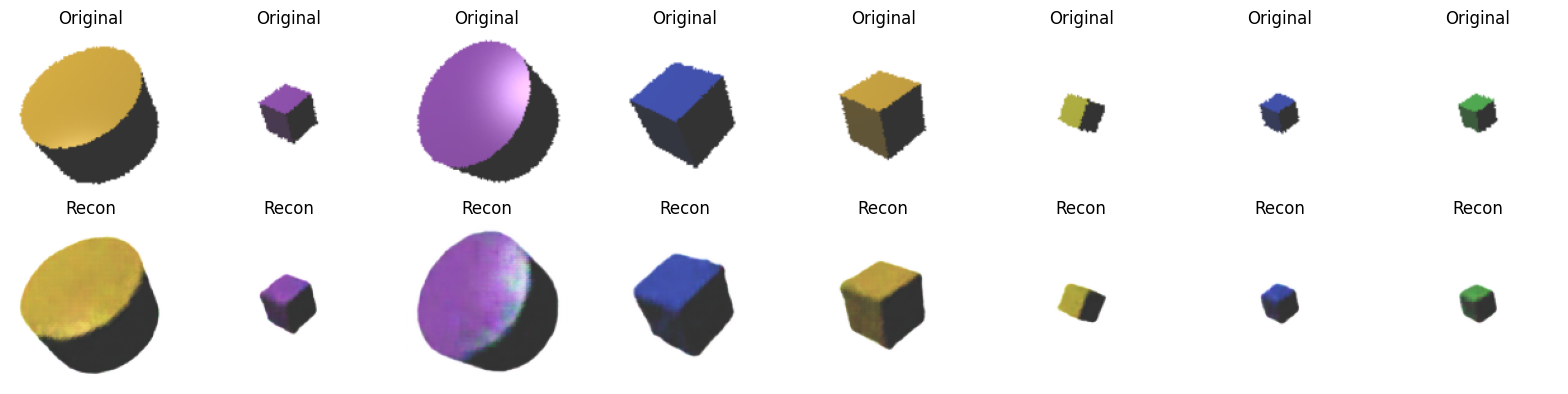

In [59]:
show_reconstructions(model, test_loader, device, n=8)

In [60]:
def extract_latents(model, dataloader, device):
    model.eval()

    cubes_latents = []
    cylinders_latents = []

    with torch.no_grad():
        for data, label in dataloader:

            data = data.to(device)
            label = label.to(device)

            mu, logvar = model.encode(data)

            for i in range(len(label)):
                if label[i] == 0:      # cubo
                    cubes_latents.append(mu[i].cpu())
                else:                  # cilindro
                    cylinders_latents.append(mu[i].cpu())

    cubes_latents = torch.stack(cubes_latents)
    cylinders_latents = torch.stack(cylinders_latents)

    return cubes_latents, cylinders_latents

In [61]:
cubes_latents, cylinders_latents = extract_latents(model, test_loader, device)

print("Cubes:", cubes_latents.shape)
print("Cylinders:", cylinders_latents.shape)

cm = cubes_latents.mean(dim= 0)
cym = cylinders_latents.mean(dim = 0)

z1 = cm
z2 = cm 

z2 = torch.tensor([0.12, 0, 0, 0])

Cubes: torch.Size([204, 8])
Cylinders: torch.Size([196, 8])


In [62]:
model.eval()

with torch.no_grad():
    z2 = z2.unsqueeze(0)
    h = model.decode(z2)

img = h[0].cpu().permute(1, 2, 0).numpy()  

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title("Interpolação cubo → cilindro")
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x4 and 8x16384)

In [63]:
import matplotlib.pyplot as plt
import torch

model.eval()

# média dos cubos (base latente)
base1 = cubes_latents.mean(dim=0)
base2 = torch.cat([
    cubes_latents.mean(dim=0)[:1],
    cylinders_latents.mean(dim=0)[1:]
])
# valores que vamos testar na dimensão 0
vals = torch.linspace(0, 1.5,25)

images = []

with torch.no_grad():

    for v in vals:
        z = base1.clone()
        z[0] = v     # varia a dimensão da classe

        z = z.unsqueeze(0).to(device)

        img = model.decode(z)[0].cpu()
        images.append(img)

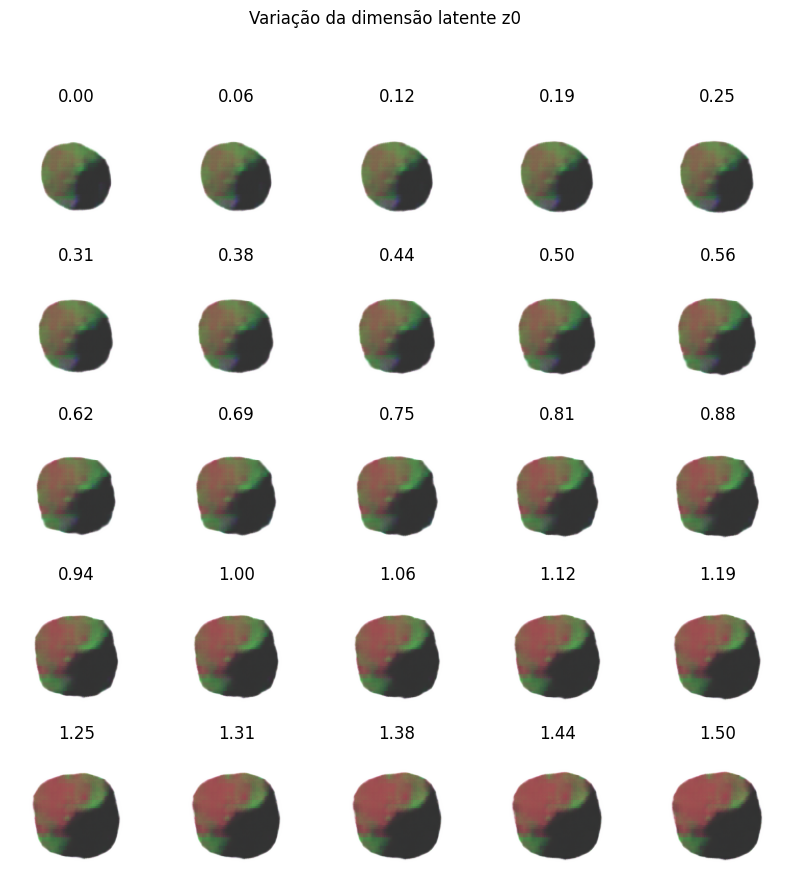

In [64]:
fig, axes = plt.subplots(5,5, figsize=(10,10))

for i, ax in enumerate(axes.flatten()):

    img = images[i].permute(1,2,0).numpy()

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{vals[i]:.2f}")

plt.suptitle("Variação da dimensão latente z0")
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x4 and 8x16384)

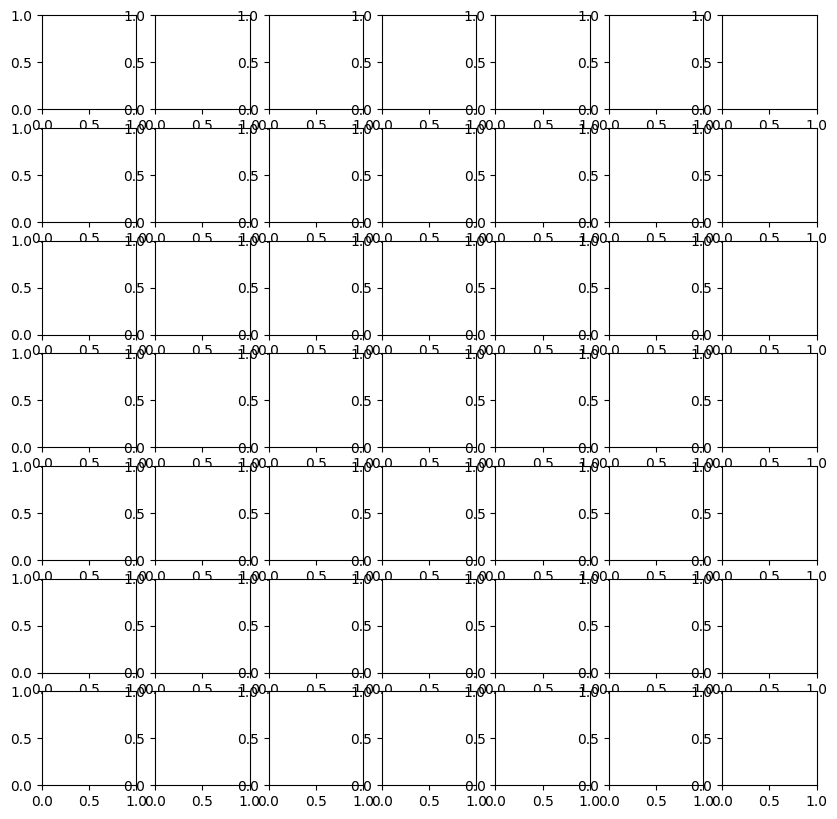

In [65]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Configurações do grid
grid_size = 7  # Vai gerar um grid 7x7
limit = 0.25    # O quão longe vamos explorar no espaço latente (ex: de -2 a +2)

# Criando as variações para o eixo X (dimensão 1) e eixo Y (dimensão 2)
dim1_range = np.linspace(-limit, limit, grid_size)
dim2_range = np.linspace(limit, -limit, grid_size) # Invertido para o Y crescer para cima

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

model.eval() # Modo de avaliação (desliga dropout/batchnorm)

with torch.no_grad(): # Não precisamos calcular gradientes para gerar imagens
    for i, val2 in enumerate(dim2_range):
        for j, val1 in enumerate(dim1_range):
            
            # 2. Montando o vetor latente z
            # - dim 0: Fixo em 0.12 (como você pediu)
            # - dim 1: Varia no eixo X (colunas do grid)
            # - dim 2: Varia no eixo Y (linhas do grid)
            # - dim 3: Fixo na média dos cubos (cm[3]) para não virar bagunça
            z = torch.tensor([[0.05, val1, val2, cm[3].item()]], dtype=torch.float32).to(device)
            
            # 3. Passando o vetor pelo Decoder
            # O output será [1, 3, Altura, Largura]
            img_tensor = model.decode(z)
            
            # 4. Preparando para o Matplotlib
            # Remove o batch dimensão (squeeze) e reorganiza de (C, H, W) para (H, W, C)
            img = img_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
            
            # O Matplotlib gosta de imagens float entre 0 e 1 (seu decoder já tem Sigmoid, então está OK)
            axes[i, j].imshow(img)
            axes[i, j].axis('off') # Esconde os eixos numéricos de cada sub-plot

plt.subplots_adjust(wspace=0.05, hspace=0.05) # Reduz o espaço em branco entre as imagens
plt.suptitle("Navegando no Espaço Latente (z[0] fixo em 0.12)", fontsize=16, y=0.92)
plt.show()

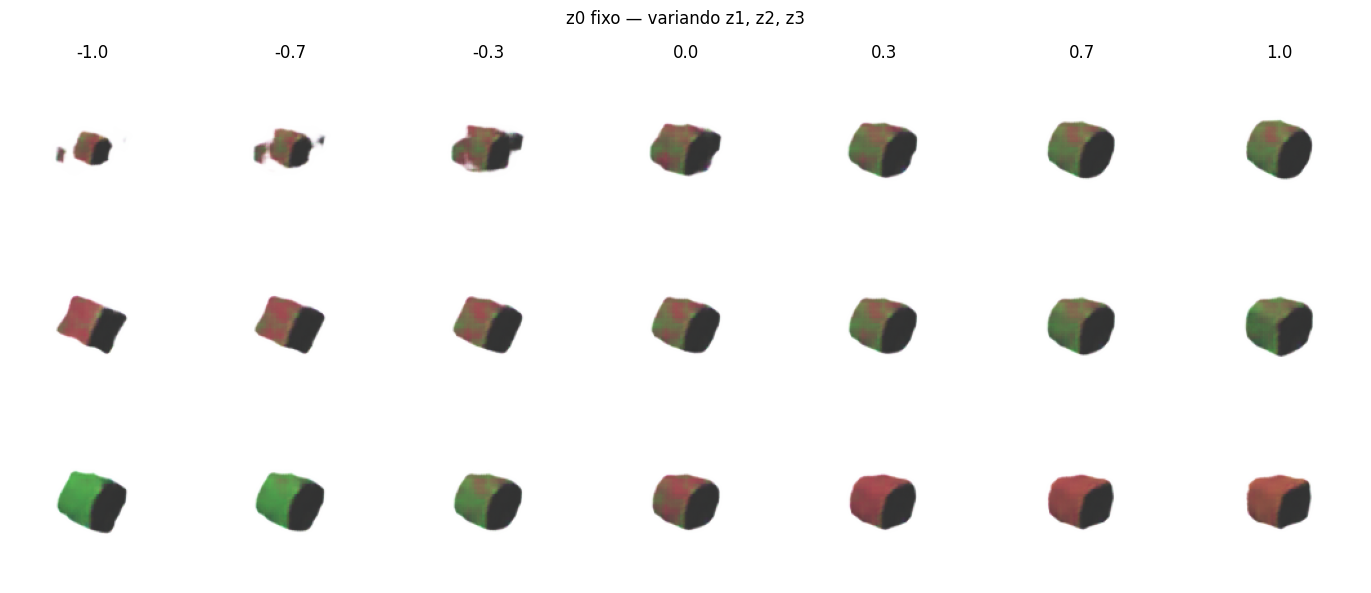

In [66]:
import matplotlib.pyplot as plt
import torch

model.eval()

base = cubes_latents.mean(dim=0)

vals = torch.linspace(-1, 1, 7)

dims = [1,2,3]

fig, axes = plt.subplots(len(dims), len(vals), figsize=(14,6))

with torch.no_grad():

    for row, dim in enumerate(dims):

        for col, v in enumerate(vals):

            z = base.clone()

            z[0] = base[0]   # z0 FIXO
            z[dim] = v       # varia uma dimensão

            z = z.unsqueeze(0).to(device)

            img = model.decode(z)[0].cpu()

            axes[row,col].imshow(img.permute(1,2,0))
            axes[row,col].axis("off")

            if row == 0:
                axes[row,col].set_title(f"{v:.1f}")

        axes[row,0].set_ylabel(f"z{dim}")

plt.suptitle("z0 fixo — variando z1, z2, z3")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()


base1 = cubes_latents.mean(dim=0)
base2 = torch.cat([
    cubes_latents.mean(dim=0)[:1],
    cylinders_latents.mean(dim=0)[1:]
])

vals = torch.linspace(-1, 1, 25)

images = []

with torch.no_grad():

    for v in vals:
        z = base2.clone()
        z[0] = v     # varia a dimensão da classe

        z = z.unsqueeze(0).to(device)

        img = model.decode(z)[0].cpu()
        images.append(img)

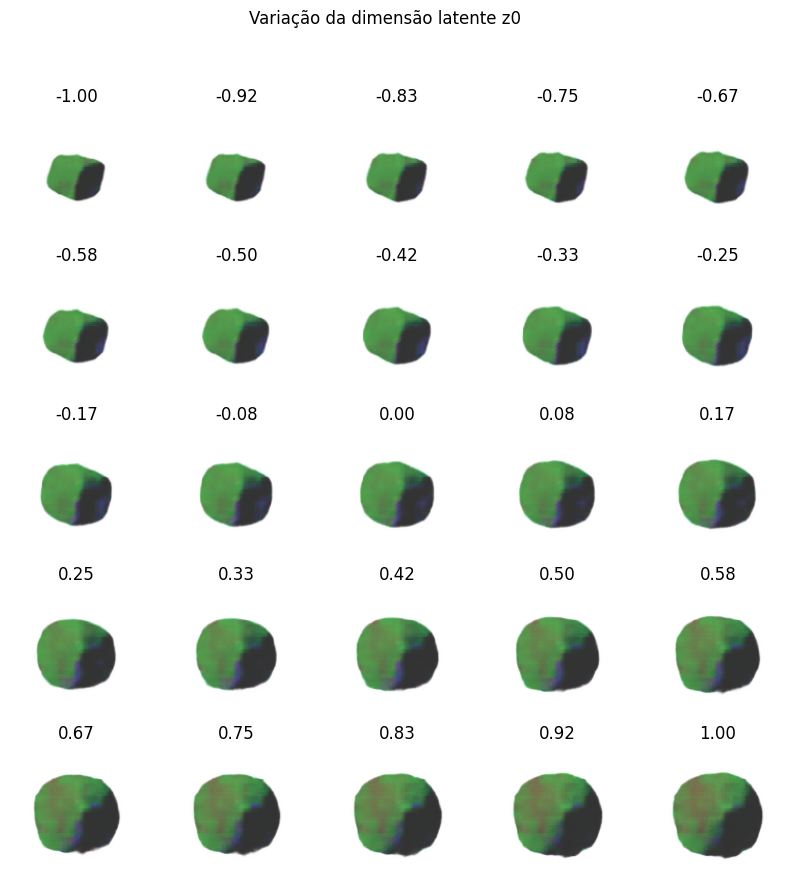

In [68]:
fig, axes = plt.subplots(5,5, figsize=(10,10))

for i, ax in enumerate(axes.flatten()):

    img = images[i].permute(1,2,0).numpy()

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{vals[i]:.2f}")

plt.suptitle("Variação da dimensão latente z0")
plt.show()

In [ ]:
import torch
import numpy as np
from PIL import Image

model.eval()


base_latents = torch.cat([
    cubes_latents.mean(dim=0)[:1],
    cylinders_latents.mean(dim=0)[1:]
])


vals = torch.linspace(-4.0, 4.0, 60)

pil_images = []

with torch.no_grad():
    for v in vals:
        z = base_latents.clone()
        z[0] = v    
        z = z.unsqueeze(0).to(device)

        img_tensor = model.decode(z)[0].cpu()
        
        img_np = img_tensor.permute(1, 2, 0).numpy()
        

        img_np = (img_np * 255).astype(np.uint8)
        
        # Cria a imagem e adiciona na lista
        pil_images.append(Image.fromarray(img_np))

# 4. Efeito Bumerangue (ida e volta para um loop perfeito)
# Pega a lista (menos o último frame), inverte a ordem e gruda no final
pil_images_loop = pil_images + pil_images[-2::-1]

# 5. Salvando o GIF
gif_path = 'mzz.gif'

pil_images_loop[0].save(
    gif_path,
    save_all=True,
    append_images=pil_images_loop[1:],
    duration=50,  # 50 milissegundos por frame (20 FPS, bem suave!)
    loop=0        # 0 significa loop infinito
)

print(f"✅ GIF salvo com sucesso como '{gif_path}'!")

✅ GIF salvo com sucesso como 'mzz.gif'!


In [72]:
import torch
import matplotlib.pyplot as plt


def plot_latent_space(model, dataloader, device):

    model.eval()

    zs = []
    labels = []

    with torch.no_grad():

        for data, label in dataloader:

            data = data.to(device)

            mu, logvar = model.encode(data)

            zs.append(mu.cpu())
            labels.append(label)

    z = torch.cat(zs)
    labels = torch.cat(labels)

    z0 = z[:,0]
    z1 = z[:,1]

    plt.figure(figsize=(6,6))

    plt.scatter(
        z0[labels==0],
        z1[labels==0],
        alpha=0.5,
        label="class 0"
    )

    plt.scatter(
        z0[labels==1],
        z1[labels==1],
        alpha=0.5,
        label="class 1"
    )

    plt.xlabel("z0 (should contain class)")
    plt.ylabel("z1 (should NOT contain class)")

    plt.legend()
    plt.show()

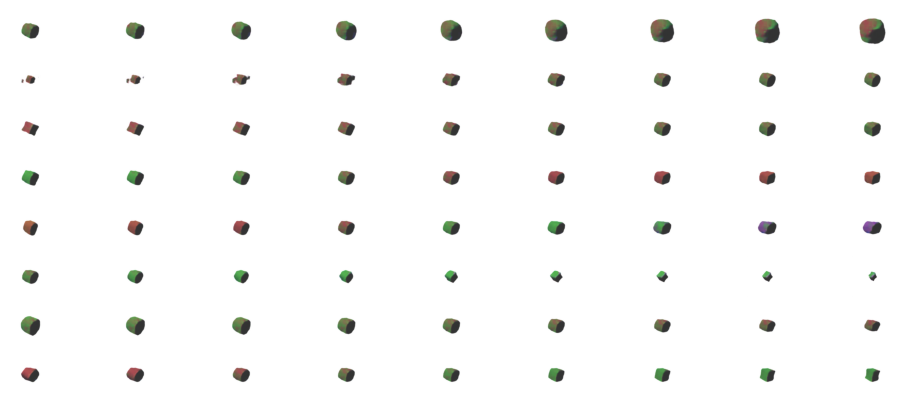

In [73]:
fig, axes = plt.subplots(latent_dim, 9, figsize=(12,5))

vals = torch.linspace(-1,1,9)

for d in range(latent_dim):

    for i,v in enumerate(vals):

        z = base.clone()
        z[d] = v

        img = model.decode(z.unsqueeze(0).to(device))[0].detach().cpu()

        axes[d,i].imshow(img.permute(1,2,0))
        axes[d,i].axis("off")

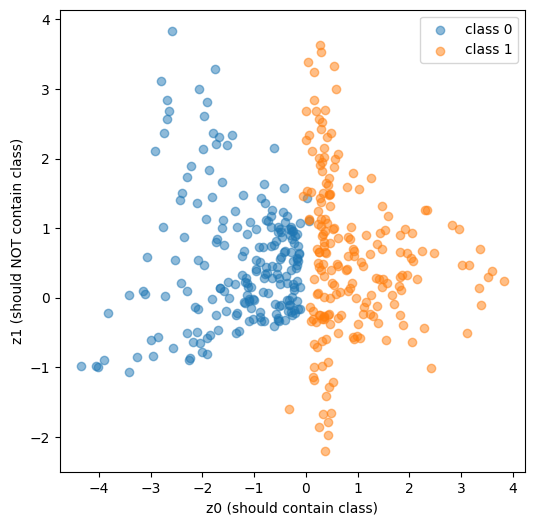

In [28]:
plot_latent_space(model, test_loader, device)